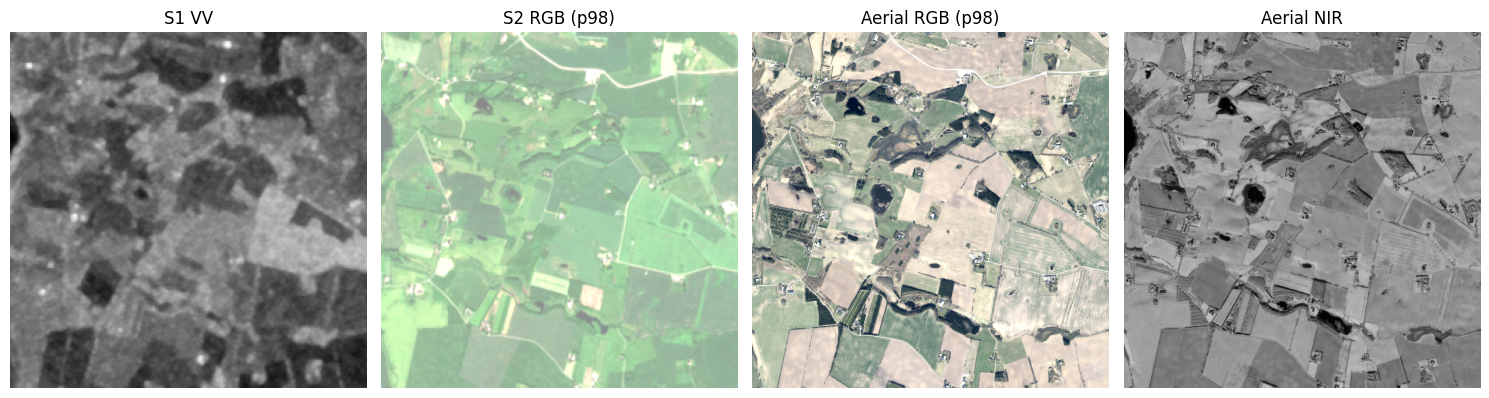

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Pick one NPZ file
p = "/home/jakob/Bachelorprojekt/Kode/pipeline5-aerial/data/tiles_npz/larger_test__S2B_MSIL2A_20250612T102559_N0511_R108_20250612T131505__S1multi7_20250611T170847_r3072_c2560.npz"
d = np.load(p, allow_pickle=True)

# S1 (VV)
s1_vv = d["s1"][0]

# S2 true color (B04,B03,B02)
s2 = d["s2"]
s2_rgb = np.stack([s2[3], s2[2], s2[1]], axis=-1).astype(np.float32)

# Aerial RGB + NIR
a = d["aerial"].astype(np.float32)
a_rgb = np.stack([a[0], a[1], a[2]], axis=-1)
a_nir = a[3]

def stretch_percentile(rgb, p=98):
    vals = rgb[np.any(rgb > 0, axis=-1)]
    scale = np.percentile(vals, p) if vals.size else 1.0
    return np.clip(rgb / (scale + 1e-6), 0, 1)

s2_rgb = stretch_percentile(s2_rgb, p=98)
a_rgb = stretch_percentile(a_rgb, p=98)

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1); plt.title("S1 VV"); plt.imshow(s1_vv, cmap="gray"); plt.axis("off")
plt.subplot(1, 4, 2); plt.title("S2 RGB (p98)"); plt.imshow(s2_rgb); plt.axis("off")
plt.subplot(1, 4, 3); plt.title("Aerial RGB (p98)"); plt.imshow(a_rgb); plt.axis("off")
plt.subplot(1, 4, 4); plt.title("Aerial NIR"); plt.imshow(a_nir, cmap="gray"); plt.axis("off")
plt.tight_layout()
plt.show()

